In [1]:
# Download some digit images from MNIST dataset
!wget -q "https://learnopencv.com/wp-content/uploads/2024/07/mnist_0.jpg" -O "mnist_0.jpg"
!wget -q "https://learnopencv.com/wp-content/uploads/2024/07/mnist_1.jpg" -O "mnist_1.jpg"

In [7]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [8]:
print("Pytorch Version ", torch.__version__)

Pytorch Version  2.10.0+cu128


### Converting Images to Batched Tensors


(-0.5, 27.5, 27.5, -0.5)

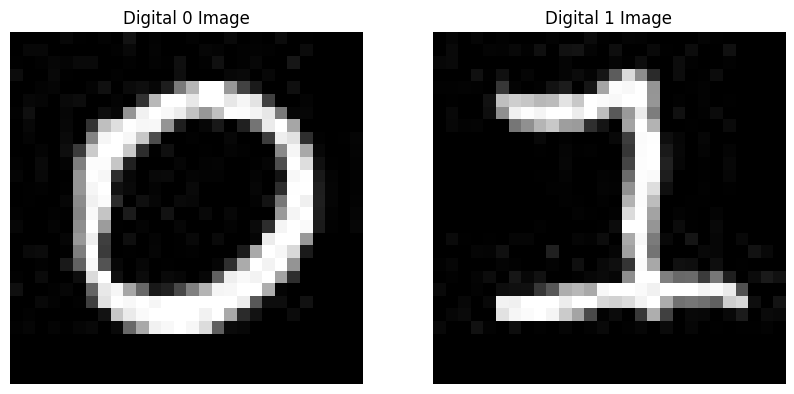

In [9]:
digit_0_array_og = cv2.imread("./images/module_1/mnist_0.jpg", cv2.IMREAD_COLOR_BGR)
digit_1_array_og = cv2.imread("./images/module_1/mnist_1.jpg", cv2.IMREAD_COLOR_BGR)

digit_0_array_gray = cv2.imread("./images/module_1/mnist_0.jpg", cv2.IMREAD_GRAYSCALE)
digit_1_array_gray = cv2.imread("./images/module_1/mnist_1.jpg", cv2.IMREAD_GRAYSCALE)

# visualize the image
fig, axs = plt.subplots(1,2, figsize=(10,5))

axs[0].imshow(digit_0_array_og, cmap='gray')
axs[0].set_title("Digital 0 Image")
axs[0].axis("off")


axs[1].imshow(digit_1_array_og, cmap='gray')
axs[1].set_title("Digital 1 Image")
axs[1].axis("off")

In [10]:
# Numpy array with three channel
print("Image array shape: ", digit_0_array_og.shape)
print(f"Min pixel value: {np.min(digit_0_array_og)} and Max pixel value: {np.max(digit_0_array_og)}")

# Numpy array with one grayscale channel
print("Image array shape: ", digit_0_array_gray.shape)
print(f"Min pixel value: {np.min(digit_0_array_gray)} and Max pixel value: {np.max(digit_0_array_gray)}")

Image array shape:  (28, 28, 3)
Min pixel value: 0 and Max pixel value: 255
Image array shape:  (28, 28)
Min pixel value: 0 and Max pixel value: 255


#### Convert Numpy array to Torch tensors

Shape of Normalized Digit 0 Tensor:  torch.Size([28, 28, 3])
Min pixel value: 0.0, Max pixel value: 1.0


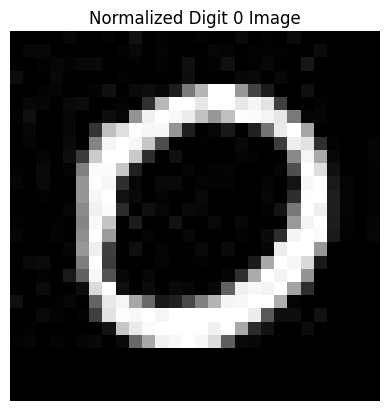

In [11]:
# Convert images to tensors and normalize
img_tensor_0 = torch.tensor(digit_0_array_og, dtype=torch.float32) / 255.0
img_tensor_1 = torch.tensor(digit_1_array_og, dtype=torch.float32) / 255.0

print("Shape of Normalized Digit 0 Tensor: ", img_tensor_0.shape)
print(f"Min pixel value: {torch.min(img_tensor_0)}, Max pixel value: {torch.max(img_tensor_0)}")

plt.imshow(img_tensor_0, cmap="gray")
plt.title("Normalized Digit 0 Image")
plt.axis("off")
plt.show()

#### Create Input Batch

In [12]:
batch_tensor = torch.stack([img_tensor_0, img_tensor_1])

print("Batch Tensor Shape: ", batch_tensor.shape)

Batch Tensor Shape:  torch.Size([2, 28, 28, 3])


Additionally, pytorch expects image tensor typically in the format [N,C,H,W] 

In [14]:
batch_input = batch_tensor.permute(0,3,1,2)

print("Batch input Shape: ", batch_input.shape)

Batch input Shape:  torch.Size([2, 3, 28, 28])


#### Introduction to tensor and its operation

#### 2.1 Construct your first Tensor

In [15]:
a = torch.ones(5)
print(a)

b = torch.zeros(5)
print(b)

tensor([1., 1., 1., 1., 1.])
tensor([0., 0., 0., 0., 0.])


In [17]:
c = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(c)

tensor([[1., 2.],
        [3., 4.]])


In [23]:
d = torch.zeros(2,3)
print(f"d: {d} {d.shape}")

e = torch.ones(3,2)
print(f"e: {e} {e.shape}")

f = torch.tensor([[1.1, 2.2],[3.3, 4.4]])
print(f"f: {f} {f.shape}")

g = torch.tensor([[[1.11, 2.22],[3.33, 4.44]],[[5.55, 6.66],[7.77, 8.88]]])
print(f"g: {g} {g.shape}")

d: tensor([[0., 0., 0.],
        [0., 0., 0.]]) torch.Size([2, 3])
e: tensor([[1., 1.],
        [1., 1.],
        [1., 1.]]) torch.Size([3, 2])
f: tensor([[1.1000, 2.2000],
        [3.3000, 4.4000]]) torch.Size([2, 2])
g: tensor([[[1.1100, 2.2200],
         [3.3300, 4.4400]],

        [[5.5500, 6.6600],
         [7.7700, 8.8800]]]) torch.Size([2, 2, 2])


#### Access element in tensor

In [24]:
print(f[1,0])

print(f[1][0])

print(g[1,0,0])
print(g[1][0][0])

tensor(3.3000)
tensor(3.3000)
tensor(5.5500)
tensor(5.5500)


In [25]:
#All element
print(f[:])

#All element from 1 to 2 (inclusive)
print(b[1:3])

#All element till 4 (exclusive)
print(b[:4])

#First row
print(f[0,:])

#second row
print(f[1,:])

tensor([[1.1000, 2.2000],
        [3.3000, 4.4000]])
tensor([0., 0.])
tensor([0., 0., 0., 0.])
tensor([1.1000, 2.2000])
tensor([3.3000, 4.4000])


#### Specify data type of elements 

In [26]:
int_tensor = torch.tensor([[1,2,3],[4,5,6]])
print(int_tensor.dtype)

int_tensor = torch.tensor([[1,2,3],[4.,5,6]])
print(int_tensor.dtype)

float_tensor = torch.tensor([[1,2,3],[4.,5, 6]])
print(float_tensor)
int_tensor = float_tensor.type(torch.int32)
print(int_tensor)

torch.int64
torch.float32
tensor([[1., 2., 3.],
        [4., 5., 6.]])
tensor([[1, 2, 3],
        [4, 5, 6]], dtype=torch.int32)


#### Tensor to/from NumPy Array

In [27]:
# Tensor to Numpy
f_numpy = f.numpy()
print(f_numpy)

# Array to Tensor
h = np.array([[2,3,4],[5,6,7]])
h_tensor = torch.from_numpy(h)
print(h_tensor)

[[1.1 2.2]
 [3.3 4.4]]
tensor([[2, 3, 4],
        [5, 6, 7]])


#### Arithmetic Operations on Tensor

In [29]:
tensor1 = torch.tensor([[1,2],[4,5]])
tensor2 = torch.tensor([[-1,2],[4,-5]])

print(tensor1 + tensor2)

print(tensor1.add(tensor2))

print(tensor1 - tensor2)

print(torch.sub(tensor1, tensor2))

print(tensor1 * 2)

#Elementwise Multiplication
print(tensor1 * tensor2)

#Matrix Multiplication
print(torch.mm(tensor1, tensor2))

#Division
print(tensor2/2)

#Elementwise division
print(tensor2/tensor1)

tensor([[0, 4],
        [8, 0]])
tensor([[0, 4],
        [8, 0]])
tensor([[ 2,  0],
        [ 0, 10]])
tensor([[ 2,  0],
        [ 0, 10]])
tensor([[ 2,  4],
        [ 8, 10]])
tensor([[ -1,   4],
        [ 16, -25]])
tensor([[  7,  -8],
        [ 16, -17]])
tensor([[-0.5000,  1.0000],
        [ 2.0000, -2.5000]])
tensor([[-1.,  1.],
        [ 1., -1.]])


#### Broadcasting

In [30]:
a = torch.tensor([1,2,3])
b = torch.tensor([4])

print(a + b)

tensor([5, 6, 7])


In [32]:
a_row = torch.tensor([1,2,3])
b_col = torch.tensor([[4],[5],[6]])

print(a_row + b_col)

tensor([[5, 6, 7],
        [6, 7, 8],
        [7, 8, 9]])


#### CPU vs GPU Tensor

In [35]:
tensor_cpu = torch.tensor([[1.0, 3.0], [2.0, 4.0]], device='cpu')
#tensor_gpu = torch.tensor([[2.0, 4.0], [1.0, 3.0]], device='cuda')

In [38]:
#tensor_gpu_cpu = tensor_gpu.to(device='cpu')
#tensor_cpu_gpu = tensor_cpu.to(device='cuda')

In [39]:
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[5, 6], [7, 8]])
c = torch.tensor([[2], [2]])

In [41]:
a,b,c

(tensor([[1, 2],
         [3, 4]]),
 tensor([[5, 6],
         [7, 8]]),
 tensor([[2],
         [2]]))

In [42]:
d = a + b
print(d)

tensor([[ 6,  8],
        [10, 12]])


In [43]:
e = d * c
print(e)

tensor([[12, 16],
        [20, 24]])
